Total bytes: 13421772800
Possible shape (12800, 512, 512) with dtype=<class 'numpy.float32'> order=C


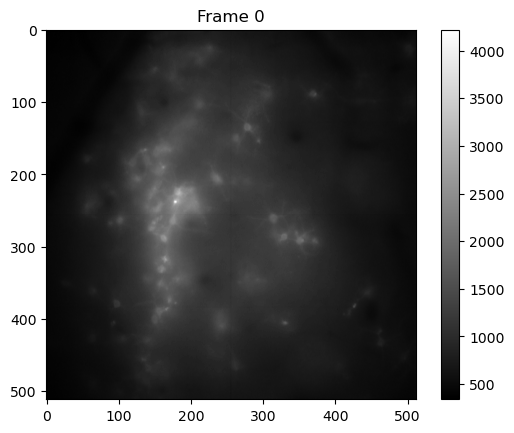

Possible shape (12800, 512, 512) with dtype=<class 'numpy.float32'> order=F


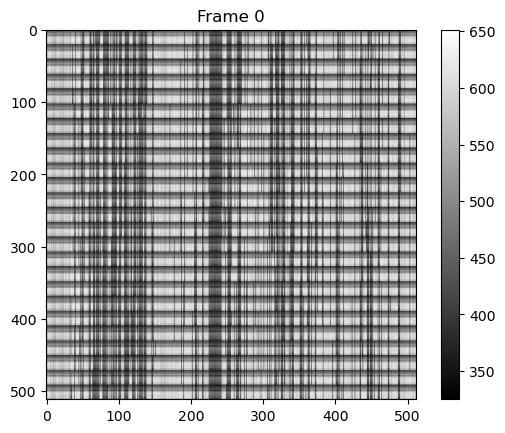

Possible shape (51200, 256, 256) with dtype=<class 'numpy.float32'> order=C


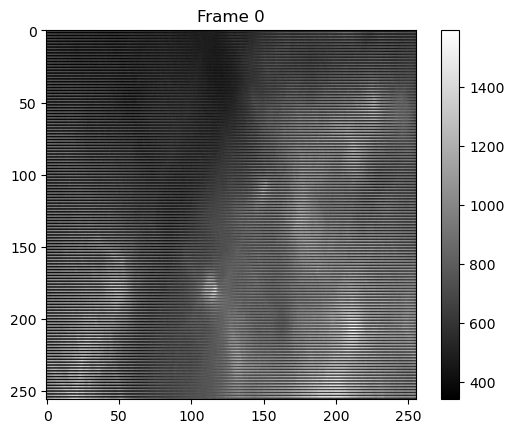

Possible shape (51200, 256, 256) with dtype=<class 'numpy.float32'> order=F


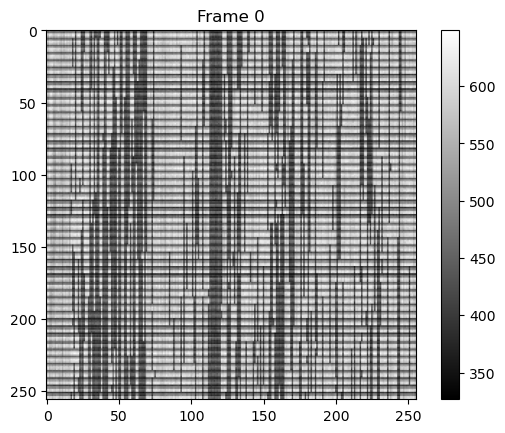

Possible shape (3200, 1024, 1024) with dtype=<class 'numpy.float32'> order=C


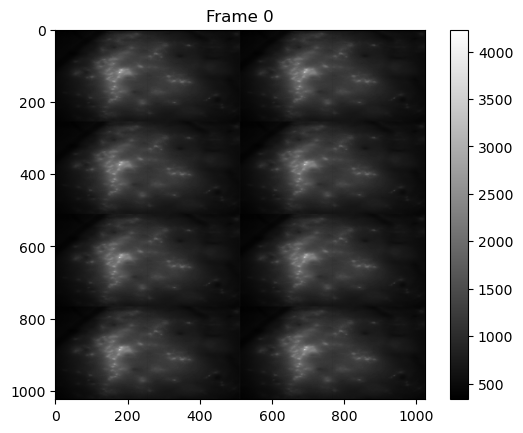

In [1]:
import mmap
import numpy as np
import matplotlib.pyplot as plt

def open_mmap(path):
    f = open(path, "rb")
    mm = mmap.mmap(f.fileno(), length=0, access=mmap.ACCESS_READ)
    return f, mm

def try_infer_shape(mm, w, h, dtype=np.float32, order='C'):
    """
    Try reshaping memory into (n_frames, h, w).
    Returns array view or None if not possible.
    """
    dtype_size = np.dtype(dtype).itemsize
    total_bytes = mm.size()
    frame_size = w * h * dtype_size
    if total_bytes % frame_size != 0:
        return None
    n_frames = total_bytes // frame_size
    arr = np.ndarray((n_frames, h, w), 
                     buffer=mm, dtype=dtype, order=order)
    return arr

def show_frame(arr, idx=0):
    """Show a frame using matplotlib."""
    plt.imshow(arr[idx], cmap='gray')
    plt.title(f"Frame {idx}")
    plt.colorbar()
    plt.show()


if __name__ == "__main__":
   #path = r'C:\Users\ICNLab\caiman_data\testdata\testdata\FOV1_T2new\memmap__d1_512_d2_512_d3_1_order_C_frames_12800.mmap'  #--> shape (12800, 512, 512) with dtype=<class 'numpy.float32'> order=F
    path = r'R:\FOV1_T2_rig__d1_512_d2_512_d3_1_order_F_frames_12800.mmap'  #--> Possible shape (12800, 512, 512) with dtype=<class 'numpy.float32'> order=F

    f, mm = open_mmap(path)
    print("Total bytes:", mm.size())

    # Try different guesses:
    candidates = [
        (512, 512, np.float32, 'C'),
        (512, 512, np.float32, 'F'),
        (256, 256, np.float32, 'C'),
        (256, 256, np.float32, 'F'),
        (1024, 1024, np.float32, 'C'),
    ]

    for w, h, dtype, order in candidates:
        arr = try_infer_shape(mm, w, h, dtype, order)
        if arr is not None:
            print(f"Possible shape {arr.shape} with dtype={dtype} order={order}")
            show_frame(arr, 0)

    mm.close()
    f.close()
